In [1]:
!pip install yfinance matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from IPython.display import display
import logging

In [3]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [4]:
def clean_data(df):
    logging.info("Standardizing column names")
    df.columns = [str(col).strip().lower().replace(' ', '_') for col in df.columns]
    df.drop_duplicates(inplace=True)

    logging.info("Handling missing values")
    num_cols = df.select_dtypes(include=['number']).columns
    imputer = SimpleImputer(strategy='median')
    df[num_cols] = imputer.fit_transform(df[num_cols])
    df.fillna("Unknown", inplace=True)

    logging.info("Converting date columns")
    for col in df.select_dtypes(include=['object']).columns:
        try:
            df[col] = pd.to_datetime(df[col])
        except ValueError:
            continue

    logging.info("Handling outliers")
    for col in num_cols:
        q1, q3 = df[col].quantile([0.05, 0.95])
        df[col] = np.clip(df[col], q1, q3)

    logging.info("Normalizing numerical values")
    scaler = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    return df

In [5]:
ticker = input("Enter stock ticker (e.g., AAPL, TSLA, MSFT): ").upper()
logging.info(f"Fetching data for {ticker}")

data = yf.download(ticker, period="1y", interval="1d")
data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data.columns]
data.reset_index(inplace=True)

logging.info("Data successfully fetched")

Enter stock ticker (e.g., AAPL, TSLA, MSFT): AAPL


2025-02-12 19:31:45,494 - INFO - Fetching data for AAPL
[*********************100%***********************]  1 of 1 completed
2025-02-12 19:31:45,969 - INFO - Data successfully fetched


In [6]:
cleaned_df = clean_data(data)
logging.info("Data cleaning completed")

2025-02-12 19:31:45,984 - INFO - Standardizing column names
2025-02-12 19:31:45,987 - INFO - Handling missing values
2025-02-12 19:31:45,993 - INFO - Converting date columns
2025-02-12 19:31:45,994 - INFO - Handling outliers
2025-02-12 19:31:46,001 - INFO - Normalizing numerical values
2025-02-12 19:31:46,004 - INFO - Data cleaning completed


In [7]:
cleaned_df.to_csv(f'cleaned_{ticker}.csv', index=False)
display(cleaned_df.head())
logging.info(f"Cleaned data saved as cleaned_{ticker}.csv")

,date,close_aapl,high_aapl,low_aapl,open_aapl,volume_aapl
0,2024-02-12,-0.996445,-1.006705,-0.943929,-0.943913,-0.680459
1,2024-02-13,-1.079184,-1.102842,-1.074674,-1.048315,0.134954
2,2024-02-14,-1.114084,-1.129417,-1.117325,-1.066044,0.029956
3,2024-02-15,-1.125455,-1.170060,-1.160774,-1.135777,0.627322
4,2024-02-16,-1.186236,-1.155992,-1.148019,-1.140899,-0.242580


2025-02-12 19:31:46,037 - INFO - Cleaned data saved as cleaned_AAPL.csv


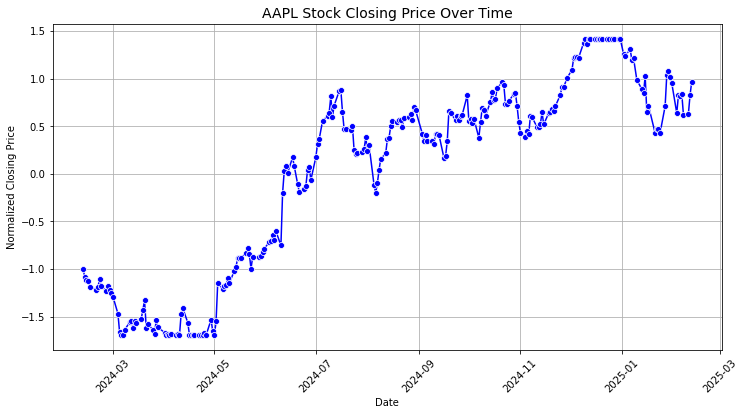

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=cleaned_df, x="date", y="close_" + ticker.lower(), marker='o', color='b')
plt.title(f"{ticker} Stock Closing Price Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Closing Price")
plt.xticks(rotation=45)
plt.grid()
plt.show()

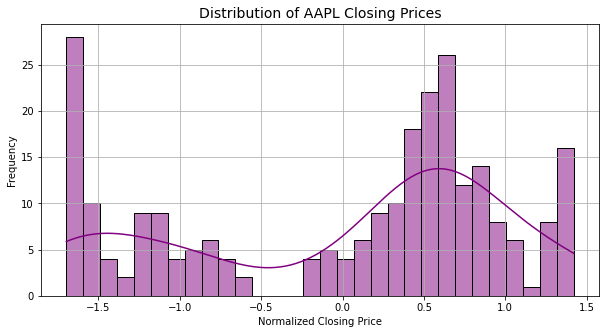

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(cleaned_df["close_" + ticker.lower()], bins=30, kde=True, color='purple')
plt.title(f"Distribution of {ticker} Closing Prices", fontsize=14)
plt.xlabel("Normalized Closing Price")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [10]:
report = cleaned_df.describe().T
report.to_csv(f'stock_report_{ticker}.csv')
display(report)
logging.info(f"Summary report saved as stock_report_{ticker}.csv")

,count,mean,std,min,25%,50%,75%,max
close_aapl,252.0,1.630089e-17,1.00199,-1.696396,-1.002982,0.414825,0.710575,1.419166
high_aapl,252.0,-3.846130e-16,1.00199,-1.708687,-1.022923,0.419671,0.724330,1.393504
low_aapl,252.0,-3.524518e-16,1.00199,-1.675904,-0.970452,0.407957,0.717233,1.439124
open_aapl,252.0,2.312965e-16,1.00199,-1.694865,-0.980720,0.406973,0.715934,1.424655
volume_aapl,252.0,-2.202823e-17,1.00199,-1.175188,-0.733978,-0.244535,0.481366,2.506561


2025-02-12 19:31:46,376 - INFO - Summary report saved as stock_report_AAPL.csv


In [11]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
